### Pneumonia classifier dataset analysis
###### __________________________________________________________________________________________________________
#### In this notebook the kaggle dataset is downloaded and analysed:
##### 1. Download and organise the kaggle dataset into: test, train and validation sets.
##### 2. Checking number of samples per class, and if any data impalance exist.
##### 3. Visual images inspection
##### 4. Image Dimension Analysis
##### 5. Pixel Value Analysis

In [ ]:
# If kagglehub is not installed, make sure to install it
!pip install kagglehub

In [ ]:
# Install open cv if not installed
!pip install opencv-python

In [7]:
# Import dependencies
import random
import matplotlib.pyplot as plt
from PIL import Image
from PIL import ImageFile
import numpy as np
import matplotlib.pyplot as plt # Import matplotlib for showing plots
import cv2 # For images reading

### 1. Download and organise the kaggle dataset

In [7]:
# Import PneumoniaDatasetDoenloader.py 
# This file contains functions that download kaggle dataset and read images from downloaded folders
# The Dataset is download path depends on the operating system, and is not downloaded on the repository local path
import src.PneumoniaDatasetDownloaderService

In [11]:
# Get the kaggle dataset by calling "load_dataset_structure" function
# This function checks if kaggle dataset is already downloaded, Otherwise it downloads the kaggle dataset
# And sorts the images by train/test/val => NORMAL/PNEUMONIA
# Returning a dictionary: {
#     "Test_Normal": [...],
#     "Train_Normal": [...],
#     "Val_Normal": [...],
#     "Test_Pneumonia": [...],
#     "Train_Pneumonia": [...],
#     "Val_Pneumonia": [...]
# }
# The Dataset is download path depends on the operating system, and is not downloaded on the repository local path
dataset = PneumoniaDatasetDownloaderService.load_Pneumonia_X_Ray_dataset()

Test_Normal = dataset["Test_Normal"]
Train_Normal = dataset["Train_Normal"]
Val_Normal = dataset["Val_Normal"]
Test_Pneumonia = dataset["Test_Pneumonia"]
Train_Pneumonia = dataset["Train_Pneumonia"]
Val_Pneumonia = dataset["Val_Pneumonia"]

Dataset already exists.


### 2. Checking number of samples per class and data impalance

In [17]:
# Show number of images for each dataset category
for key, value in dataset.items():
    print(key, len(value))

Train_Normal 1341
Train_Pneumonia 3875
Test_Normal 234
Test_Pneumonia 390
Val_Normal 8
Val_Pneumonia 8


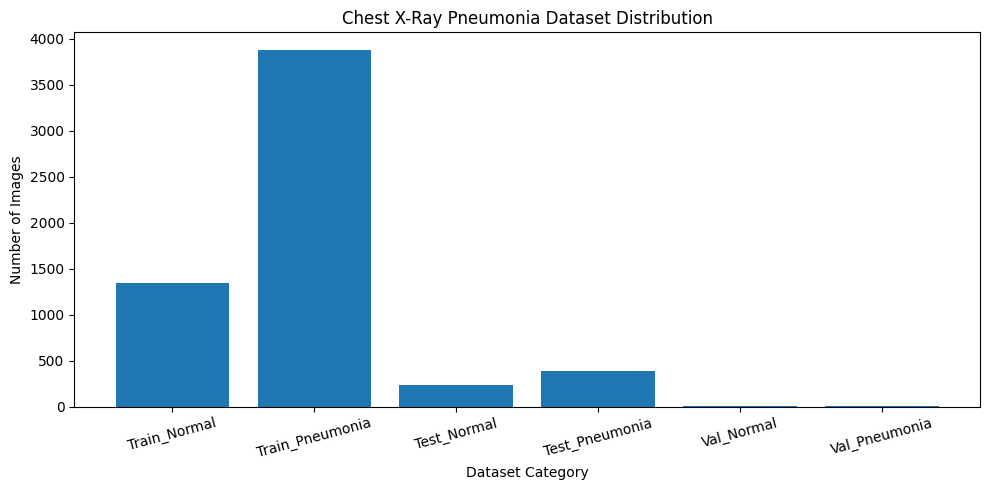

Dataset Split Summary
------------------------------
Training Images   : 5216
Testing Images    : 624
Validation Images : 16

Training Ratio    : 89.07%
Testing Ratio     : 10.66%
Validation Ratio  : 0.27%


In [34]:
# Graph Chest X-Ray Pneumonia Dataset Distribution 
def graph_dataset_distribution(dataset):
    """
    Graph the number of images in each dataset category.
    """

    categories = []
    counts = []

    for key, value in dataset.items():
        categories.append(key)
        counts.append(len(value))

    plt.figure(figsize=(10, 5))

    plt.bar(categories, counts)

    plt.title("Chest X-Ray Pneumonia Dataset Distribution")
    plt.xlabel("Dataset Category")
    plt.ylabel("Number of Images")

    plt.xticks(rotation=15)

    plt.tight_layout()
    plt.show()

def show_dataset_split_ratios(dataset):
    """
    Shows total train/test/validation counts and ratios.
    """

    train_total = (
        len(dataset["Train_Normal"]) +
        len(dataset["Train_Pneumonia"])
    )

    test_total = (
        len(dataset["Test_Normal"]) +
        len(dataset["Test_Pneumonia"])
    )

    val_total = (
        len(dataset["Val_Normal"]) +
        len(dataset["Val_Pneumonia"])
    )

    total = train_total + test_total + val_total

    train_ratio = (train_total / total) * 100
    test_ratio = (test_total / total) * 100
    val_ratio = (val_total / total) * 100

    print("Dataset Split Summary")
    print("-" * 30)

    print(f"Training Images   : {train_total}")
    print(f"Testing Images    : {test_total}")
    print(f"Validation Images : {val_total}")

    print()

    print(f"Training Ratio    : {train_ratio:.2f}%")
    print(f"Testing Ratio     : {test_ratio:.2f}%")
    print(f"Validation Ratio  : {val_ratio:.2f}%")
    
graph_dataset_distribution(dataset)
show_dataset_split_ratios(dataset)

#### The dataset shows impalance:
###### ------------------------------
###### Training Images   : 5216
###### Testing Images    : 624
###### Validation Images : 16
###### Training Ratio    : 89.07%
###### Testing Ratio     : 10.66%
###### Validation Ratio  : 0.27%
###### ------------------------------
##### The dataset distribution shows class imbalance, especially in the training set:
#### Training:
######   • NORMAL = 1341
######   • PNEUMONIA = 3875
######   • Ratio ≈ 1 : 2.9
#### Testing:
######   • NORMAL = 234
######   • PNEUMONIA = 390
######   • Ratio ≈ 1 : 1.7
#### Validation:
######   • NORMAL = 8
######   • PNEUMONIA = 8
######
##### • The model may become biased toward predicting Pneumonia due to impalance.
##### • Validation set is relatively too small, a decision can be made to slplit the training dataset into training and validation dataset instead on relying on the given validation dataset.
##### • Test to training dataset is almost 1:9, which can be used in model training and testing.

### 3. Visual inspection

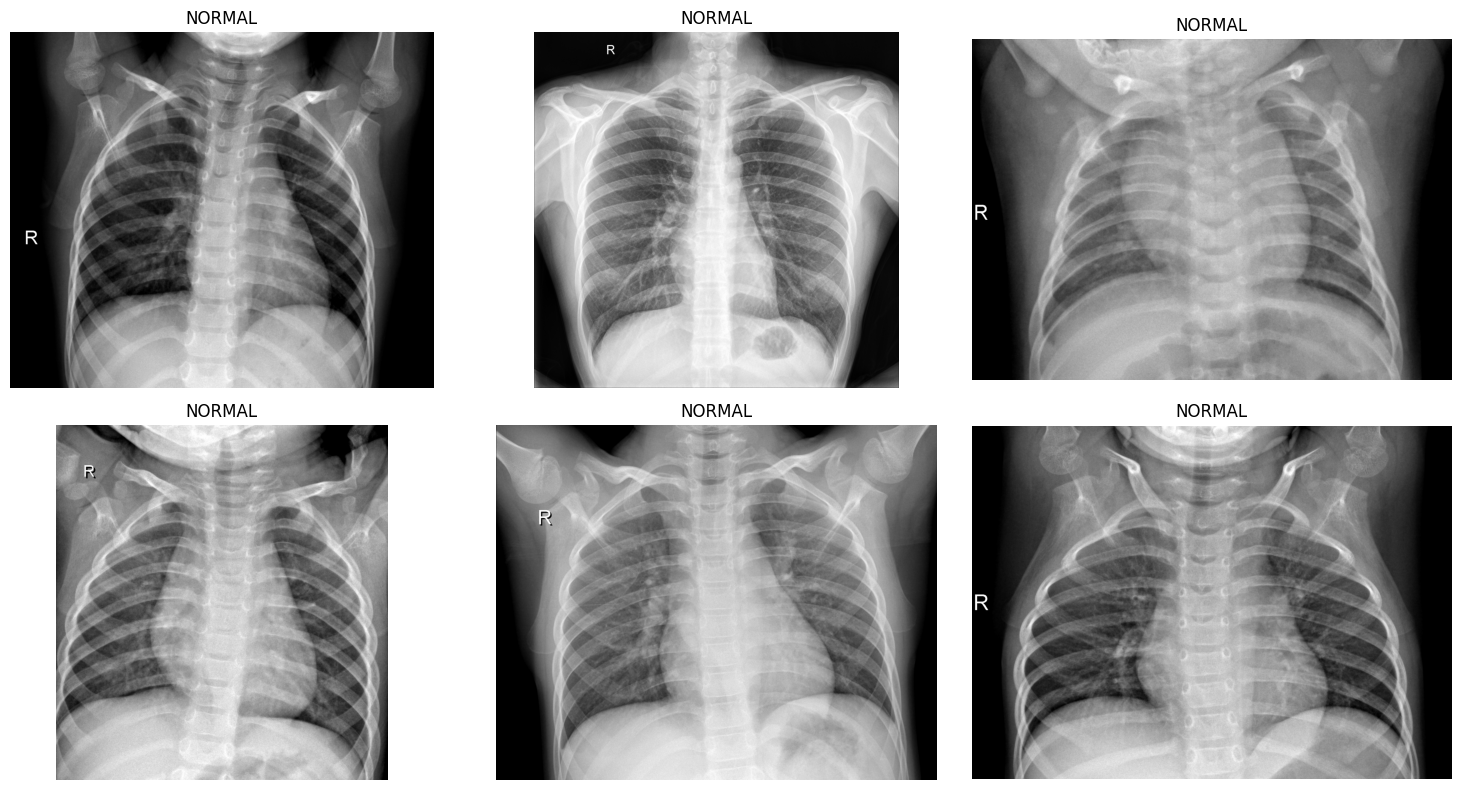

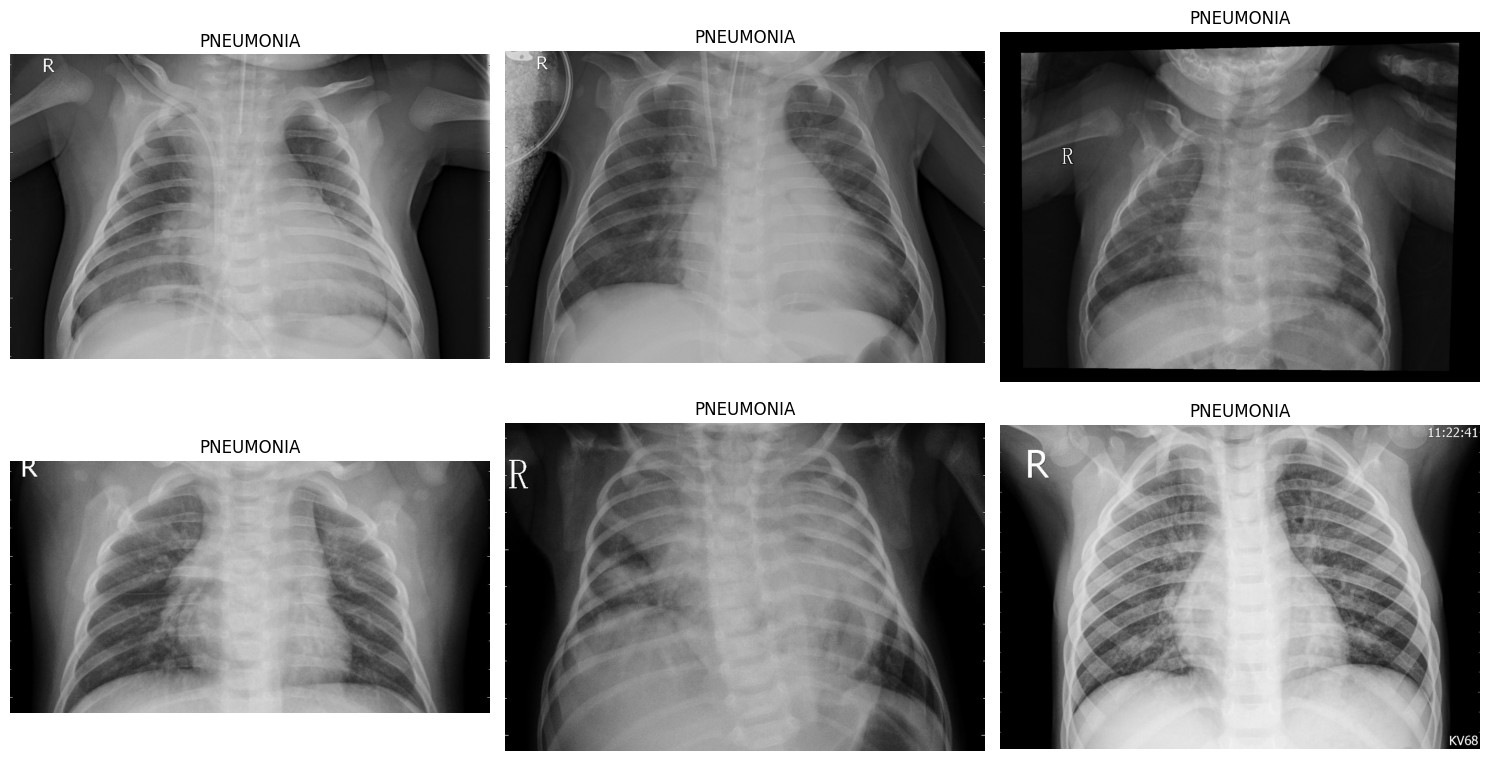

In [62]:
# Show images from both categories
def show_random_images(image_paths, title, num_images=6):
    """
    Display random images from a dataset category.
    """
    selected_images = random.sample(image_paths, min(num_images, len(image_paths)))
    plt.figure(figsize=(15, 8))
    for index, image_path in enumerate(selected_images):
        image = Image.open(image_path)
        plt.subplot(2, 3, index + 1)
        plt.imshow(image, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_random_images(dataset["Train_Normal"], title="NORMAL")
show_random_images(dataset["Train_Pneumonia"], title="PNEUMONIA")

#### Image inspection results:
##### From the printed images, it seems the image sizes are not uniform, image dimension alaysis might be required.

### 4. Image dimension analysis

In [76]:
# Show images dimensions through whole dataset, retreiving the maximum, minimum and average images sizes
def analyze_image_dimensions(dataset):
    """
    Analyze image dimensions across the whole dataset.
    """
    widths = []
    heights = []

    all_images = []

    for image_list in dataset.values():
        all_images.extend(image_list)

    for image_path in all_images:
        try:
            image = Image.open(image_path)
            width, height = image.size
            widths.append(width)
            heights.append(height)
        except Exception as e:
            print(f"Could not read image: {image_path}")
            print(e)
            
    print("Image Dimension Analysis")
    print("-" * 35)
    print(f"Total Images Analyzed : {len(widths)}")
    print()
    print(f"Minimum Width  : {min(widths)}")
    print(f"Maximum Width  : {max(widths)}")
    print(f"Average Width  : {sum(widths) / len(widths):.2f}")
    print()
    print(f"Minimum Height : {min(heights)}")
    print(f"Maximum Height : {max(heights)}")
    print(f"Average Height : {sum(heights) / len(heights):.2f}")

    # Width distribution graph
    plt.figure(figsize=(10, 5))
    plt.hist(widths, bins=30)
    plt.title("Image Width Distribution")
    plt.xlabel("Width")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
    
    # Height distribution graph
    plt.figure(figsize=(10, 5))
    plt.hist(heights, bins=30)
    plt.title("Image Height Distribution")
    plt.xlabel("Height")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

Image Dimension Analysis
-----------------------------------
Total Images Analyzed : 5856

Minimum Width  : 384
Maximum Width  : 2916
Average Width  : 1327.88

Minimum Height : 127
Maximum Height : 2713
Average Height : 970.69


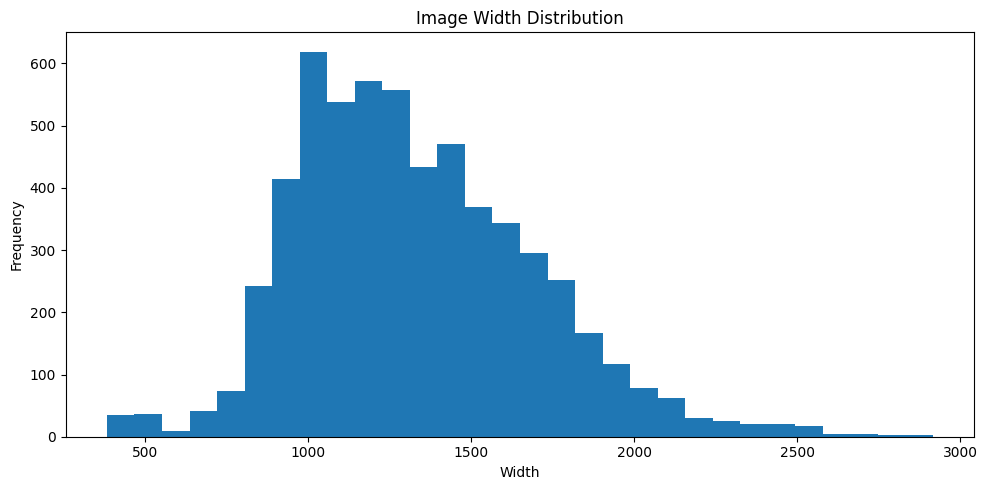

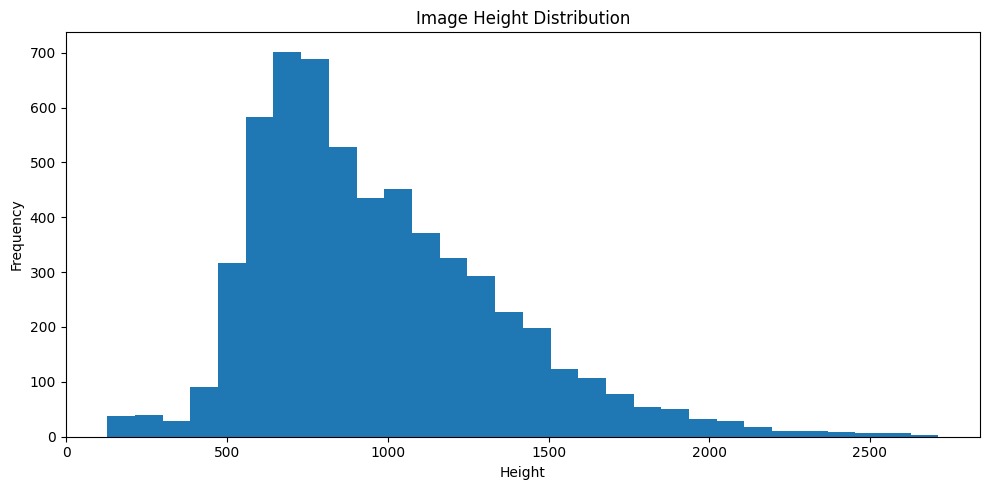

In [71]:
analyze_image_dimensions(dataset)

#### Image dimensions analysis Results:

###### -----------------------------------
###### Total Images Analyzed : 5856
###### Minimum Width  : 384
###### Maximum Width  : 2916
###### Average Width  : 1327.88
###### Minimum Height : 127
###### Maximum Height : 2713
###### Average Height : 970.69
###### -----------------------------------
##### Image dimension analysis revealed significant variability in image resolutions across the dataset. 
##### Image widths ranged from 384 to 2916 pixels, while heights ranged from 127 to 2713 pixels. 
##### Due to this inconsistency, preprocessing and resizing were necessary before training the convolutional neural network. 
##### A fixed input size might be required to ensure uniform tensor dimensions and efficient model training.

### 5. Pixel Value Analysis

In [9]:
# Read pixels values for all images in the dataset, it is important to check existing pixel values as it is preferable
# that pixel values range from 0 to 1 when training the model.
# Allow loading truncated images
def analyze_pixel_values(dataset):

    total_sum = 0
    total_squared_sum = 0
    total_pixels = 0

    min_pixel = 255
    max_pixel = 0

    failed_images = 0
    histogram = np.zeros(256)
    all_images = []

    for image_list in dataset.values():
        all_images.extend(image_list)

    for image_path in all_images:
        try:
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            if image is None:
                failed_images += 1
                continue

            image = image.astype(np.float32)
            total_sum += np.sum(image)
            total_squared_sum += np.sum(image ** 2)
            total_pixels += image.size
            min_pixel = min(min_pixel, np.min(image))
            max_pixel = max(max_pixel, np.max(image))
            hist, _ = np.histogram(image, bins=256, range=(0, 255))
            histogram += hist

        except Exception as e:
            failed_images += 1
            print("FAILED:", image_path)
            print(e)

    mean = total_sum / total_pixels

    variance = (total_squared_sum / total_pixels) - (mean ** 2)

    std = np.sqrt(variance)

    print("Pixel Value Analysis")
    print("-" * 35)
    print(f"Total Pixels Analyzed : {total_pixels}")
    print(f"Failed Images         : {failed_images}")
    print()
    print(f"Minimum Pixel Value : {min_pixel}")
    print(f"Maximum Pixel Value : {max_pixel}")
    print(f"Average Pixel Value : {mean:.2f}")
    print(f"Standard Deviation  : {std:.2f}")

    # Histogram
    plt.figure(figsize=(10, 5))

    plt.bar(range(256), histogram)

    plt.title("Pixel Intensity Distribution")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

Pixel Value Analysis
-----------------------------------
Total Pixels Analyzed : 8309130065
Failed Images         : 0

Minimum Pixel Value : 0.0
Maximum Pixel Value : 255.0
Average Pixel Value : 124.28
Standard Deviation  : 62.58


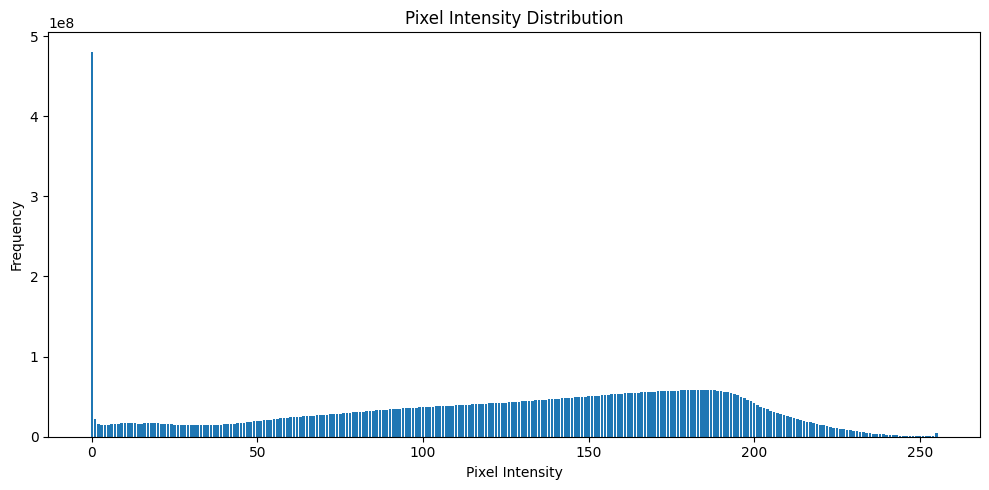

In [11]:
analyze_pixel_values(dataset)

#### Pixel values results:

###### Total Pixels Analyzed : 8309130065
###### Failed Images         : 0
###### -----------------------------------
###### Minimum Pixel Value : 0.0
###### Maximum Pixel Value : 255.0
###### Average Pixel Value : 124.28
###### Standard Deviation  : 62.58
###### -----------------------------------


##### Pixel intensity analysis showed that grayscale values ranged from 0 to 255, confirming full grayscale utilization across the dataset. 
##### The average pixel intensity was approximately 124.28 with a standard deviation of 62.58, indicating balanced brightness and substantial contrast variation. 
##### These findings suggest that the dataset contains sufficient visual diversity for effective convolutional neural network training. 
##### Pixel normalization is therefore recommended during preprocessing to improve numerical stability during model training. Normalisation to range from 0 to 1.